# Prominence in the solar corona
Magnetic field lines aren't properly drawn but it gives more or less the idea.

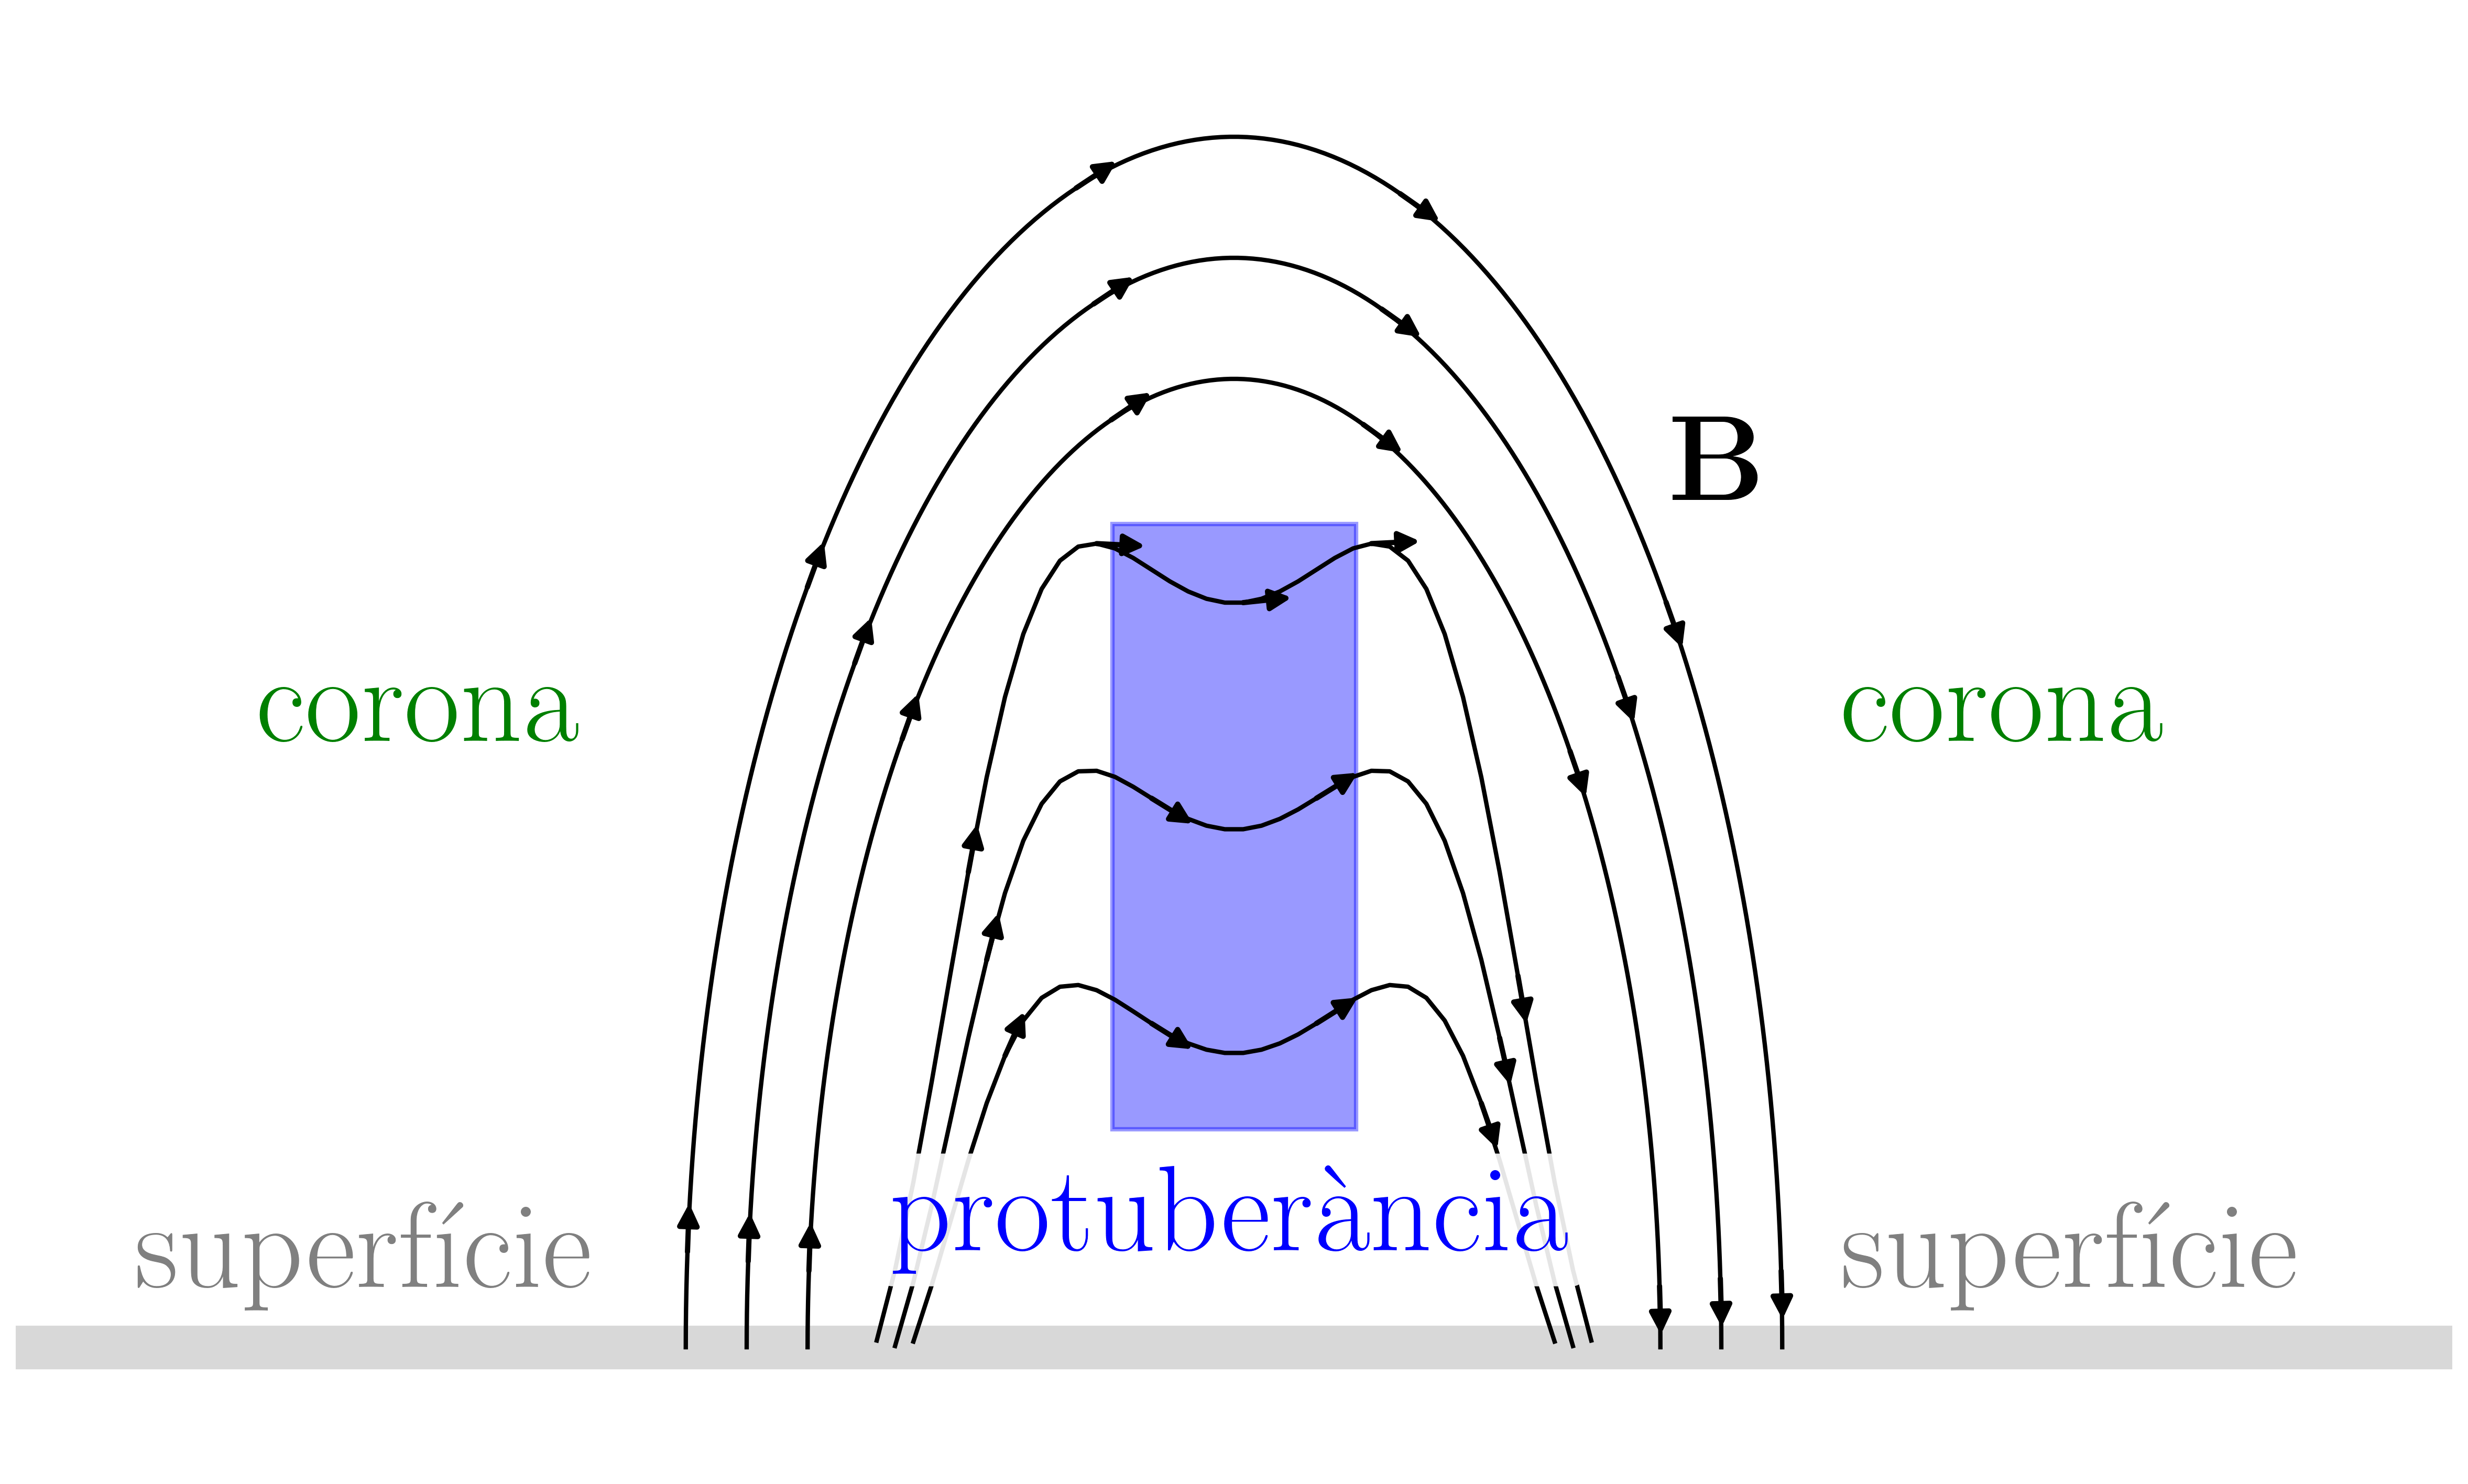

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "font.size": 20,            # Calibrat perquè aparegui com 12pt quan es redueixi a 0.48\textwidth
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.dpi": 600,            # Alta resolució
    "savefig.dpi": 600,
    "text.usetex": True,          # Usa LaTeX
    "mathtext.fontset": "cm",     # Per fer coincidir fonts matemàtiques
})



### Figura i eixos ###
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(-5, 5)
ax.set_ylim(0, 6)
ax.axis('off')



### Etiquetes regions ###
ax.text(2.5, 0.75, 'superfície', fontsize=28, color='gray')
ax.text(-4.5, 0.75, 'superfície', fontsize=28, color='gray')
ax.text(2, 4, r'$\mathbf{B}$', fontsize=28, ha='center')
ax.text(-4, 3, 'corona', color='green', fontsize=28)
ax.text(2.5, 3, 'corona', color='green', fontsize=28)
ax.text(-1.4, 0.9, 'protuberància', color='blue', fontsize=28, bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.1'))



### Protuberància solar ###
protuberancia = plt.Rectangle((-0.5, 1.4), 1, 2.5, color='blue', alpha=0.4)
ax.add_patch(protuberancia)



### Línia gruixada de la superfície ###
ax.plot([-6, 6], [0.5, 0.5], color='gray', linewidth=10, alpha=0.3)



### Línies de camp fora de les protuberàncies ###
theta = np.linspace(0, np.pi, 200)  # Només la meitat superior
radii = [1.75, 2, 2.25]  # Semieixos horitzontals (més grans = més altes)
amplitudes = [4, 4.5, 5]    # Alçada de cada el·lipse
y_offsets = [0.5, 0.5, 0.5] # Base vertical (separació entre màxims)

# Bucle per traçar-les
for r, a, y0 in zip(radii, amplitudes, y_offsets):
    x_oval = r * np.cos(theta)
    y_oval = a * np.sin(theta) + y0
    ax.plot(x_oval, y_oval, color='black')



### Línies de camp dins la protuberància ###
x = np.linspace(-15, 15, 400)
    
heights = [1.5, 2, 2.5]
scales = [1.5, 2, 1]

mask_1 = (x > -1.5) & (x < 1.5)
mask_2 = (x > -1.4) & (x < 1.4)
mask_3 = (x > -1.35) & (x < 1.35)

def smooth_field_line(x, height, width=6):
    return height * np.exp(-0.6*x**4 + 0.4*x**2 + 0.25 / width)

y = smooth_field_line(x, 3.5, width=12)
ax.plot(x[mask_1], y[mask_1], color='black', linestyle='-')

def smooth_field_line_2(x, height, width=6):
    return height * np.exp(-0.7*x**4 + 0.5*x**2 - 0.25 / width)

y = smooth_field_line_2(x, 2.75, width=6)
ax.plot(x[mask_2], y[mask_2], color='black', linestyle='-')

def smooth_field_line_3(x, height, width=6):
    return height * np.exp(-0.8*x**4 + 0.7*x**2 - 0.25 / width)

y = smooth_field_line_3(x, 1.75, width=12)
ax.plot(x[mask_3], y[mask_3], color='black', linestyle='-')



### Afegeix fletxes tangents a les línies ###

# Funció per dibuixar només la punta de la fletxa (triangular)
def afegeix_fletxes_triangulars(x, y, n=5, color='black'):
    idx = np.linspace(5, len(x)-5, n, dtype=int)  # Evita extrems
    dx = gradient(x)
    dy = gradient(y)
    
    for i in idx:
        # Calculem angle normalitzat per orientar la punta
        norm = np.hypot(dx[i], dy[i])
        dxn = dx[i] / norm
        dyn = dy[i] / norm

        ax.annotate('',
            xy=(x[i] + dxn * 0.2, y[i] + dyn * 0.2),
            xytext=(x[i], y[i]),
            arrowprops=dict(arrowstyle='-|>,head_length=0.2,head_width=0.1', color=color, shrinkA=0, shrinkB=0, lw=1.2),
            annotation_clip=False)

# Línies dins la protuberància
y1 = smooth_field_line(x, 3.5, width=12)
afegeix_fletxes_triangulars(x[mask_1], y1[mask_1], n=5)

y2 = smooth_field_line_2(x, 2.75, width=6)
afegeix_fletxes_triangulars(x[mask_2], y2[mask_2], n=4)

y3 = smooth_field_line_3(x, 1.75, width=12)
afegeix_fletxes_triangulars(x[mask_3], y3[mask_3], n=4)

# Línies ovalades (el·líptiques)
for r, a, y0 in zip(radii, amplitudes, y_offsets):
    x_oval = -r * np.cos(theta)
    y_oval = a * np.sin(theta) + y0
    afegeix_fletxes_triangulars(x_oval, y_oval, n=6)


plt.savefig('prot_real.png', bbox_inches='tight', dpi=600)
plt.show()


 # Representation of the 2D problem to be solved (F&S modes)


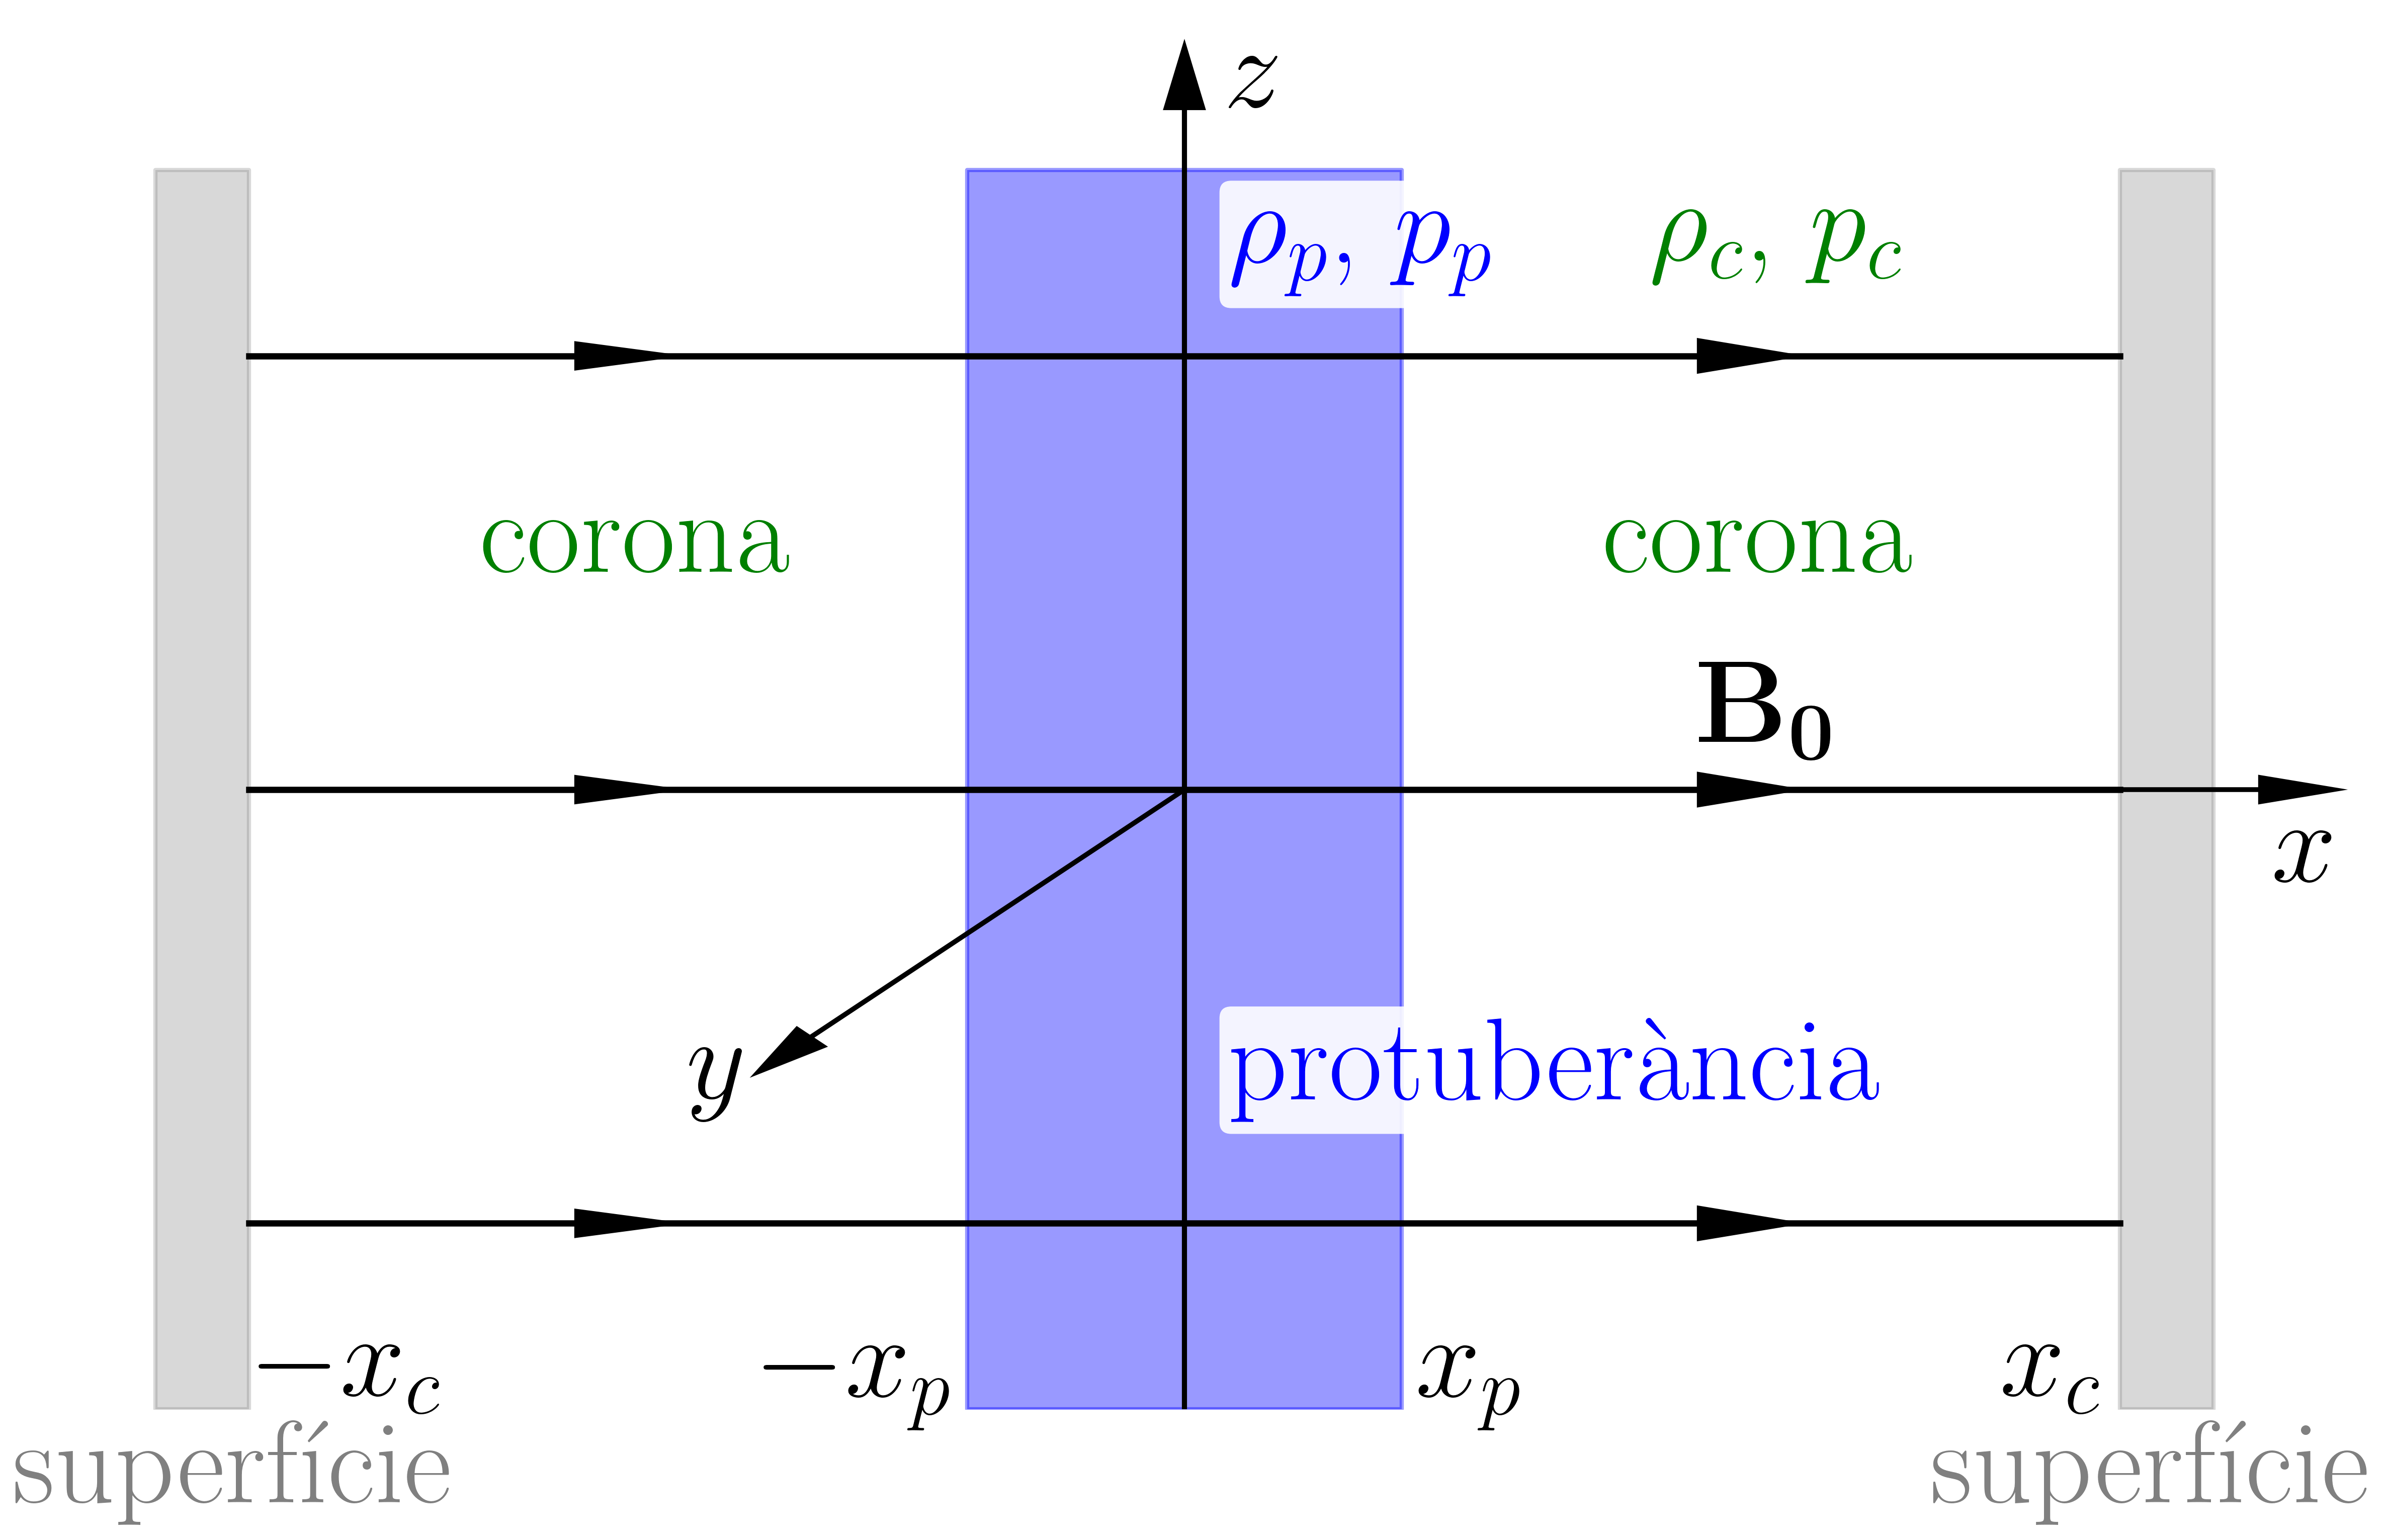

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "font.size": 20,            # Calibrat perquè aparegui com 12pt quan es redueixi a 0.48\textwidth
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.dpi": 600,            # Alta resolució
    "savefig.dpi": 600,
    "text.usetex": True,          # Usa LaTeX
    "mathtext.fontset": "cm",     # Per fer coincidir fonts matemàtiques
})


### Figura ###
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_frame_on(False)
ax.axis('off')
L = 1.0
x = np.linspace(-L, L, 100)
z = np.linspace(0, 2, 100)



### Regions ###
plt.fill_between(x, 0, 2, where=(x >= -0.25) & (x <= 0.25), color='blue', alpha=0.4, label='Protuberància')
plt.fill_betweenx(z, -L-0.1, -L, color='gray', alpha=0.3, label='Superfície')
plt.fill_betweenx(z, L, L+0.1, color='gray', alpha=0.3)



### Eixos ###
plt.arrow(0, 1, 1.15, 0, head_width=0.04, head_length=0.08, fc='black', ec='black', linewidth=1, zorder=10)
plt.arrow(0, 1, -0.4, -0.4, head_width=0.04, head_length=0.08, fc='black', ec='black', linewidth=1, zorder=10)
plt.arrow(0, 0, 0, 2.1, head_width=0.04, head_length=0.1, fc='black', ec='black', linewidth=1, zorder=10)
plt.text(1.2, 0.85, r'$x$', fontsize=28, color='black', ha='center')
plt.text(-0.5, 0.5, r'$y$', fontsize=28, color='black', ha='center')
plt.text(0.075, 2.1, r'$z$', fontsize=28, color='black', ha='center')


### Línies de camp magnètic ###
z_values = [0.3, 1.0, 1.7]
for z_val in z_values:
    plt.plot(x, [z_val]*len(x), linestyle='-', color='black', linewidth=1.5)

for z_val in z_values:
    plt.arrow(-0.65, z_val, 0.1, 0, head_width=0.04, head_length=0.1, fc='black', ec='black', length_includes_head=True)
    plt.arrow(0.55, z_val, 0.1, 0, head_width=0.05, head_length=0.1, fc='black', ec='black', length_includes_head=True)



### Etiquetes ###
ax.text(-L-0.25, -0.15, 'superfície', fontsize=28, color='gray')
ax.text(L-0.2, -0.15, 'superfície', fontsize=28, color='gray')
ax.text(-L+0.25, 1.35, 'corona', fontsize=28, color='green')
ax.text(L-0.55, 1.35, 'corona', fontsize=28, color='green')
ax.text(0.05, 0.5, 'protuberància', fontsize=28, color='blue', bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.1'))
#ax.text(-0.3, 1.95, r'$H$', fontsize=28, color='black', ha='center')
ax.text(0.55, 1.075, r'$\mathbf{B_0}$', fontsize=28, color='black')
ax.text(L - 0.125, 0.02, r'$x_c$', fontsize=28)
ax.text(-L+ 0.01, 0.02, r'$-x_c$', fontsize=28)
ax.text(L/10 + 0.15, 0.02, r'$x_p$', fontsize=28)
ax.text(-L/10 - 0.35, 0.02, r'$-x_p$', fontsize=28)
ax.text(0.5, 1.85, r'$\rho_{c}$, $p_{c}$', fontsize=28, color='green')
ax.text(0.05, 1.85, r'$\rho_{p}$, $p_{p}$', fontsize=28, color='blue', bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.1'))



plt.xlim(-L-0.25, L+0.25)
plt.ylim(0, 2.25)
plt.savefig('protuberancia_solar_2d.png', dpi=300, bbox_inches='tight')
plt.show()

# Longitudinal structure 1D string

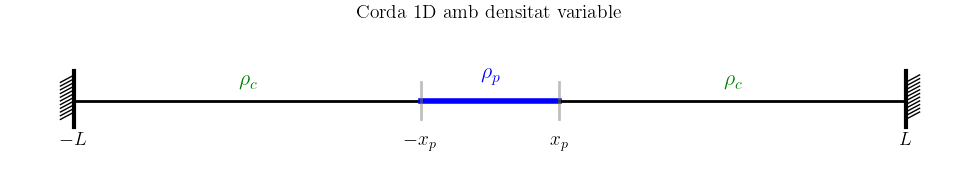

In [ ]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')

# Longituds
lc = 5
lp = 2
x0 = 0
x1 = x0 + lc
x2 = x1 + lp
x3 = x2 + lc

fig, ax = plt.subplots(figsize=(10, 2))
ax.set_xlim(-1, x3 + 1)
ax.set_ylim(-1, 1)
ax.axis('off')

# Trams de la corda
ax.plot([x0, x1], [0, 0], color='black', linewidth=2)
ax.plot([x1, x2], [0, 0], color='blue', linewidth=4)
ax.plot([x2, x3], [0, 0], color='black', linewidth=2)

# Línies als extrems (negres i gruixudes)
ax.plot([x0, x0], [-0.35, 0.4], color='black', linewidth=3)
ax.plot([x3, x3], [-0.35, 0.4], color='black', linewidth=3)

# Línies de canvi de densitat (grises)
ax.plot([x1, x1], [-0.25, 0.25], color='gray', linewidth=2, alpha=0.5)
ax.plot([x2, x2], [-0.25, 0.25], color='gray', linewidth=2, alpha=0.5)

# Etiquetes de densitat
ax.text((x0 + x1)/2, 0.2, r'$\rho_c$', fontsize=16, color='green', ha='center')
ax.text((x1 + x2)/2, 0.3, r'$\rho_p$', fontsize=16, color='blue', ha='center')
ax.text((x2 + x3)/2, 0.2, r'$\rho_c$', fontsize=16, color='green', ha='center')


# Etiquetes de longitud
ax.text((x1 + x2)/2 - 1, -0.6, r'$-x_p$', fontsize=28, color='black', ha='center')
ax.text((x1 + x2)/2 + 1, -0.6, r'$x_p$', fontsize=28, color='black', ha='center')
ax.text(0, -0.6, r'$-L$', fontsize=28, color='black', ha='center')
ax.text(12, -0.6, r'$L$', fontsize=28, color='black', ha='center')



# Suports ratllats
for x_support in [x0 , x3 + 0.2]:
    for y in range(-5, 6):
        ax.plot([x_support - 0.2, x_support], [y * 0.05, y * 0.05 + 0.1], color='black')

# Títol opcional
plt.title("Corda 1D amb densitat variable", fontsize=28)
plt.tight_layout()
plt.show()
